# B2B SaaS Sales Performance & Commercial Analytics

**End-to-end analytics project** covering data cleaning, exploratory data analysis, statistical testing,
customer segmentation, time-series forecasting, and commercial insight generation for a global B2B SaaS
sales organization.

**Author:** Arif &nbsp;|&nbsp; **Dataset:** `SaaS-Sales.csv` (9,994 transactions, 2020&ndash;2023, 48 countries)

---

### Project Goals
1. Clean and validate a raw transactional sales export.
2. Explore revenue, profit, and discount performance across Region, Segment, Industry and Product.
3. Quantify the commercial impact of discounting on profitability (a core lever for a Sales Products/Pricing role).
4. Segment customers using RFM + clustering to identify strategic accounts and churn risk.
5. Forecast future monthly revenue to support commercial planning.
6. Translate findings into **actionable recommendations** for pricing, incentive design, and account management.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---- Global styling for a consistent, presentation-ready look ----
sns.set_theme(style="whitegrid", font_scale=1.0)
PALETTE = {
    "navy": "#1F3864", "orange": "#ED7D31", "teal": "#2E8B8B",
    "green": "#2E7D32", "red": "#C62828", "gold": "#C9A227",
    "grey": "#6B7280", "purple": "#6C4AB6"
}
CAT_PALETTE = [PALETTE["navy"], PALETTE["orange"], PALETTE["teal"], PALETTE["gold"],
               PALETTE["purple"], PALETTE["green"], PALETTE["red"], PALETTE["grey"]]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#D0D3D9", "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.labelsize": 11, "font.size": 10.5
})

def money_fmt(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:,.0f}K"
    return f"${x:,.0f}"

MONEY_FORMATTER = mticker.FuncFormatter(money_fmt)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("Environment ready.")

Environment ready.

## 2. Data Loading

In [2]:
# NOTE: Update this path to wherever you keep the raw file, e.g.:
# DATA_PATH = r"C:\Users\Administrator\Desktop\GitHub Repository\B2B SaaS Sales Performance & Commercial Analytics\SaaS-Sales.csv"
DATA_PATH = "SaaS-Sales.csv"

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
display(df.head())

Rows: 9,994  |  Columns: 19

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.96,2,0.00,41.91
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.94,3,0.00,219.58
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.62,2,0.00,6.87
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.58,5,0.45,-383.03
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.37,2,0.20,2.52


## 3. Data Quality Assessment
Before any analysis, we validate structure, types, missingness, duplicates, and referential
consistency (e.g. one `Order ID` should map to one `Customer`).

In [3]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean()*100).round(2),
    "n_unique": df.nunique()
})
display(quality_report)

print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated Row IDs: {df['Row ID'].duplicated().sum()}")
print(f"Distinct Orders: {df['Order ID'].nunique():,}  |  Distinct Customers: {df['Customer'].nunique()}")
print(f"Distinct License keys: {df['License'].nunique():,} (should equal row count -> {df['License'].nunique()==len(df)})")

# Sanity check: one Order ID should not map to conflicting Customers
orders_multi_cust = df.groupby("Order ID")["Customer"].nunique()
print(f"Orders with more than one Customer attached (data integrity check): {(orders_multi_cust>1).sum()}")

Fully duplicated rows: 0
Duplicated Row IDs: 0
Distinct Orders: 5,009  |  Distinct Customers: 99
Distinct License keys: 9,994 (should equal row count -> True)
Orders with more than one Customer attached (data integrity check): 0

,dtype,n_missing,pct_missing,n_unique
Row ID,int64,0,0.00,9994
Order ID,str,0,0.00,5009
Order Date,str,0,0.00,1237
Date Key,int64,0,0.00,1237
Contact Name,str,0,0.00,793
Country,str,0,0.00,48
City,str,0,0.00,262
Region,str,0,0.00,3
Subregion,str,0,0.00,12
Customer,str,0,0.00,99


In [4]:
# Range checks on numeric fields that commonly hide data errors
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
display(df[numeric_cols].describe().T)

print("\nNegative Sales rows:", (df["Sales"] < 0).sum())
print("Discount outside [0,1]:", ((df["Discount"] < 0) | (df["Discount"] > 1)).sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

Negative Sales rows: 0
Discount outside [0,1]: 0
Quantity <= 0: 0

,count,mean,std,min,25%,50%,75%,max
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


**Findings:** the dataset is exceptionally clean with zero nulls, zero duplicate rows, valid discount range
(0&ndash;80%), and no negative sales/quantities. The only true "cleaning" needed is type conversion
(dates, categorical dtypes) and feature engineering to support the analysis below. This mirrors what a
Sales Products Officer would validate before trusting a Salesforce/CRM export.

## 4. Data Cleaning & Feature Engineering

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

# Standardize categorical columns
cat_cols = ["Country", "City", "Region", "Subregion", "Industry", "Segment", "Product"]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# Feature engineering
df["Order Year"]      = df["Order Date"].dt.year
df["Order Month"]     = df["Order Date"].dt.month
df["Order MonthName"] = df["Order Date"].dt.strftime("%b")
df["Order Quarter"]   = df["Order Date"].dt.to_period("Q").astype(str)
df["Order YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

df["Profit Margin"]   = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)
df["Unit Price"]      = df["Sales"] / df["Quantity"]
df["Is Discounted"]   = df["Discount"] > 0
df["Discount Band"]   = pd.cut(df["Discount"],
                                bins=[-0.01, 0, 0.1, 0.2, 0.3, 1],
                                labels=["0%", "1-10%", "11-20%", "21-30%", "31%+"])
df["Is Loss Making"]  = df["Profit"] < 0

# Persist a clean, analysis-ready extract for the SQL / Excel deliverables
export_cols = ["Row ID","Order ID","Order Date","Order Year","Order Quarter","Order YearMonth",
               "Contact Name","Country","City","Region","Subregion","Customer","Customer ID",
               "Industry","Segment","Product","License","Sales","Quantity","Discount","Profit",
               "Profit Margin","Unit Price","Discount Band","Is Loss Making"]
df[export_cols].to_csv("data/SaaS_Sales_Cleaned.csv", index=False)

print("Feature engineering complete. New columns added:")
print([c for c in df.columns if c not in pd.read_csv(DATA_PATH).columns])
display(df[["Order Date","Order YearMonth","Profit Margin","Discount Band","Is Loss Making"]].head())

Feature engineering complete. New columns added:
['Order Year', 'Order Month', 'Order MonthName', 'Order Quarter', 'Order YearMonth', 'Profit Margin', 'Unit Price', 'Is Discounted', 'Discount Band', 'Is Loss Making']

,Order Date,Order YearMonth,Profit Margin,Discount Band,Is Loss Making
0,2022-11-09,2022-11,0.16,0%,False
1,2022-11-09,2022-11,0.30,0%,False
2,2022-06-13,2022-06,0.47,0%,False
3,2021-10-11,2021-10,-0.40,31%+,True
4,2021-10-11,2021-10,0.11,11-20%,False


## 5. Exploratory Data Analysis

### 5.1 Revenue & Profit Trend Over Time

,Sales,Profit,YoY Growth %
Order Year,,,
2020,"484,247.50","49,543.97",NaN
2021,"470,532.51","61,618.60",-2.80
2022,"608,473.83","81,726.93",29.30
2023,"733,947.02","93,507.51",20.60


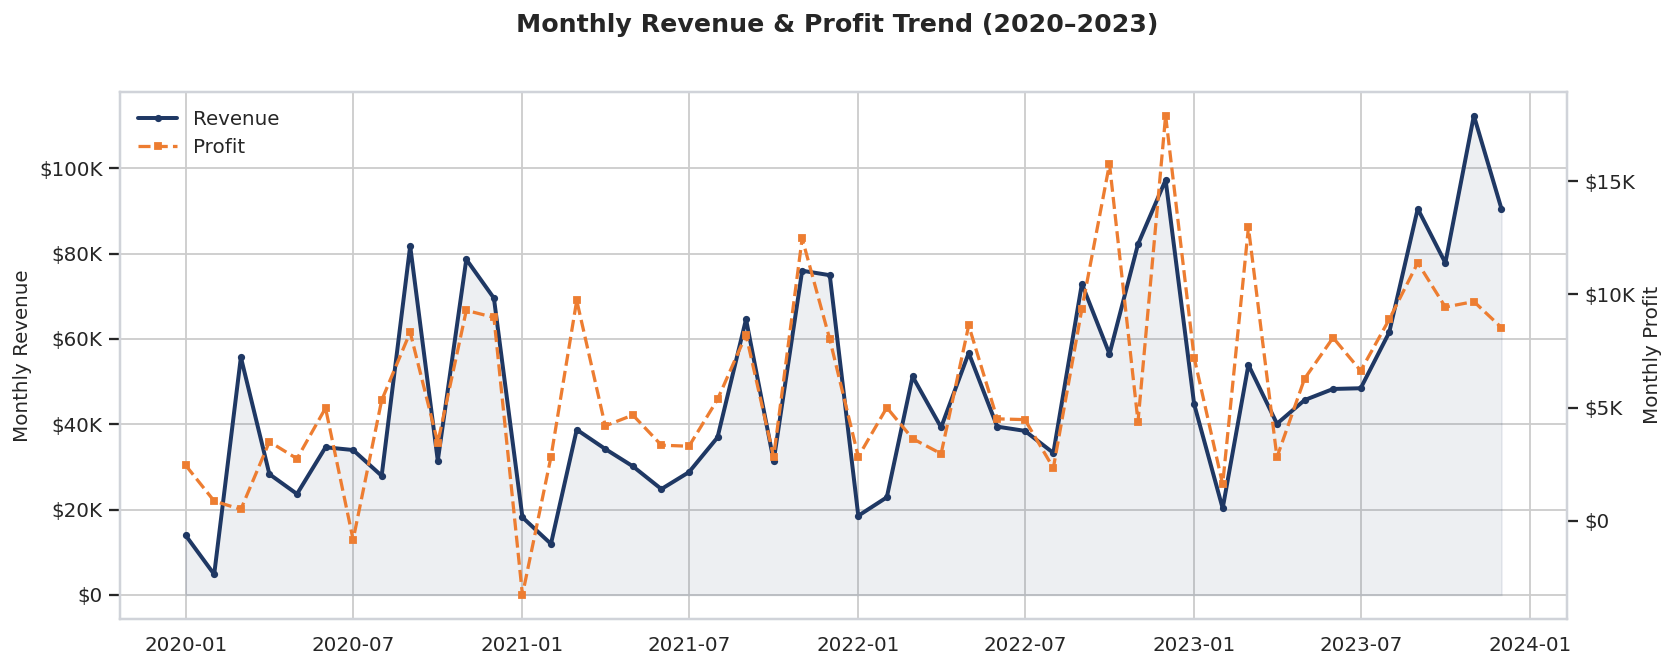

In [6]:
monthly = df.groupby(df["Order Date"].dt.to_period("M")).agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
)
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly.index, monthly["Sales"], color=PALETTE["navy"], lw=2.2, marker="o", ms=3, label="Revenue")
ax1.fill_between(monthly.index, monthly["Sales"], color=PALETTE["navy"], alpha=0.08)
ax1.set_ylabel("Monthly Revenue")
ax1.yaxis.set_major_formatter(MONEY_FORMATTER)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["Profit"], color=PALETTE["orange"], lw=1.8, ls="--", marker="s", ms=3, label="Profit")
ax2.set_ylabel("Monthly Profit")
ax2.yaxis.set_major_formatter(MONEY_FORMATTER)
ax2.grid(False)

fig.suptitle("Monthly Revenue & Profit Trend (2020\u20132023)", fontsize=14, fontweight="bold", y=1.02)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

yearly = df.groupby("Order Year").agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
yearly["YoY Growth %"] = (yearly["Sales"].pct_change()*100).round(1)
display(yearly)

**Insight:** Revenue shows strong, consistent growth with pronounced **Q4 seasonality spikes**
(a common B2B SaaS pattern driven by annual renewal/budget cycles). 2023 is on pace to be the
strongest year yet, though the last data point may reflect a partial month.

### 5.2 Revenue & Profit by Region and Segment

,Sales,Profit,Margin %
Segment,,,
Enterprise,"429,653.15","60,298.68",14.03
SMB,"1,161,401.34","134,119.21",11.55
Strategic,"706,146.37","91,979.13",13.03


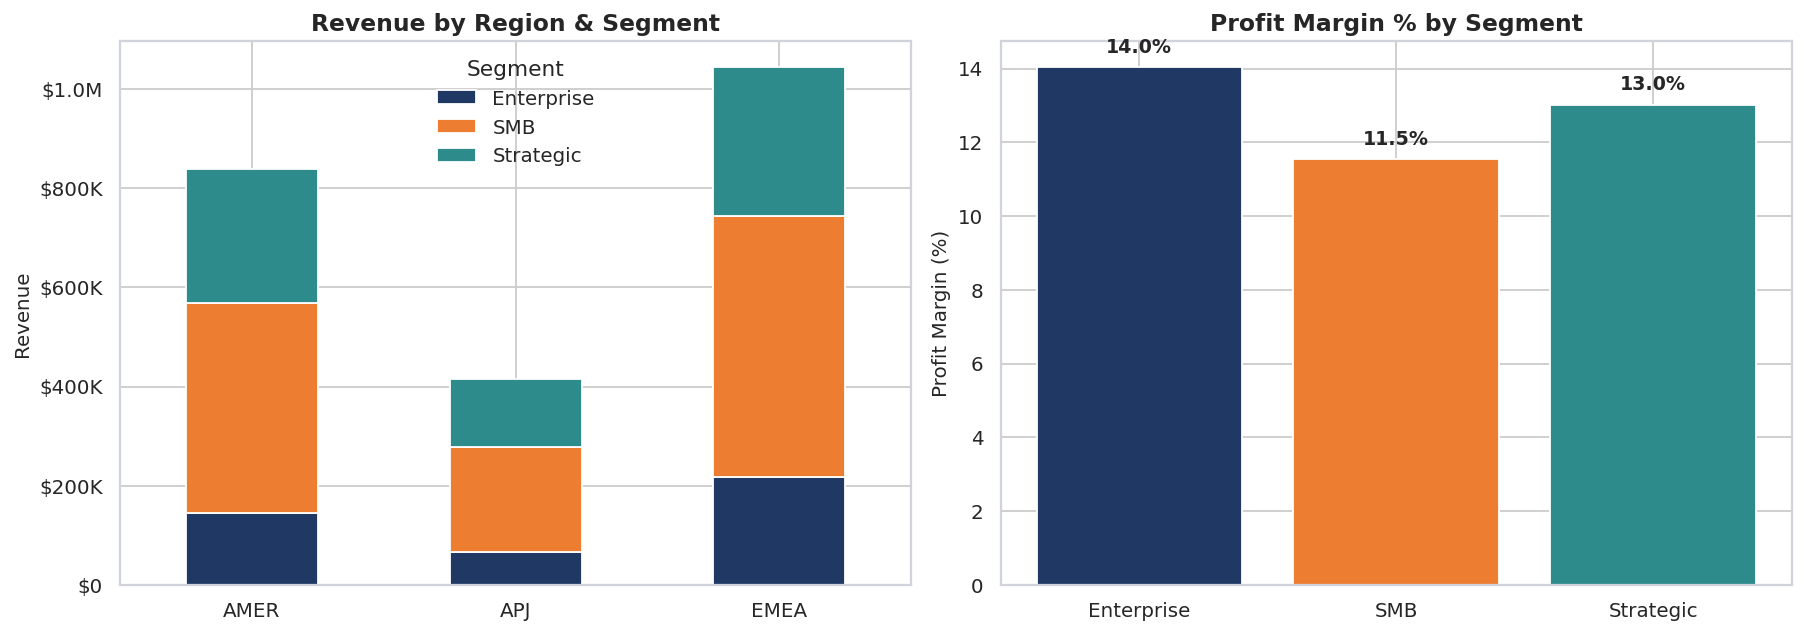

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_seg = df.groupby(["Region","Segment"])["Sales"].sum().unstack()
region_seg.plot(kind="bar", stacked=True, ax=axes[0], color=CAT_PALETTE[:3], edgecolor="white")
axes[0].set_title("Revenue by Region & Segment")
axes[0].set_ylabel("Revenue")
axes[0].yaxis.set_major_formatter(MONEY_FORMATTER)
axes[0].set_xlabel("")
axes[0].legend(title="Segment", frameon=False)
axes[0].tick_params(axis='x', rotation=0)

seg_profit = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
seg_profit["Margin %"] = (seg_profit["Profit"]/seg_profit["Sales"]*100)
ax = axes[1]
bars = ax.bar(seg_profit.index, seg_profit["Margin %"], color=[PALETTE["navy"],PALETTE["orange"],PALETTE["teal"]])
ax.set_title("Profit Margin % by Segment")
ax.set_ylabel("Profit Margin (%)")
for b, v in zip(bars, seg_profit["Margin %"]):
    ax.text(b.get_x()+b.get_width()/2, v + (0.4 if v>=0 else -0.9), f"{v:.1f}%", ha="center", fontweight="bold")
ax.axhline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()
display(seg_profit.round(2))

**Insight:** the **Enterprise** and **Strategic** segments drive the bulk of revenue, but segment
profit margins tell a different story, a segment can be revenue-heavy yet margin-light if it's
also the most heavily discounted (explored in Section 5.6). This is a classic pricing/incentive-design
signal for a Sales Products role.

### 5.3 Product Portfolio Performance

,Sales,Profit,Qty,Margin %
Product,,,,
ContactMatcher,"410,378.26","12,496.28",7215,3.05
FinanceHub,"340,935.42","32,136.42",3756,9.43
Site Analytics,"330,007.05","44,515.73",3289,13.49
Marketing Suite - Gold,"223,843.61","21,278.83",3158,9.51
Big Ol Database,"189,238.63","3,384.76",440,1.79
Data Smasher,"167,380.32","41,936.64",2976,25.05
Alchemy,"149,528.03","55,617.82",234,37.20
Support,"125,152.74","32,864.47",5825,26.26
Marketing Suite,"114,880.00","-3,472.56",868,-3.02


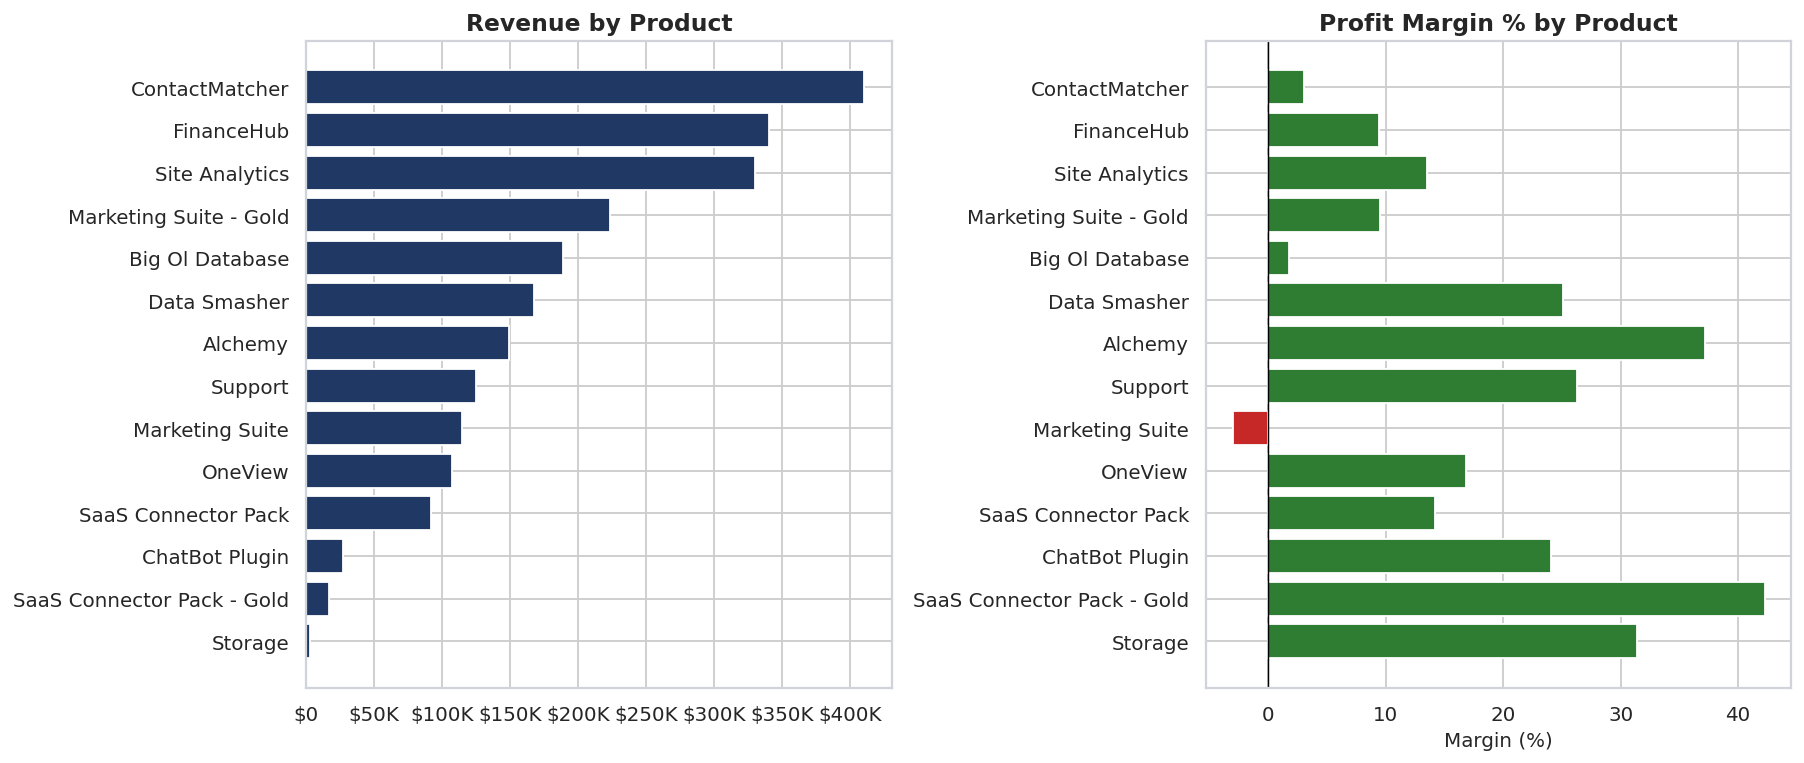

In [8]:
prod = df.groupby("Product").agg(Sales=("Sales","sum"), Profit=("Profit","sum"),
                                  Qty=("Quantity","sum")).sort_values("Sales", ascending=False)
prod["Margin %"] = prod["Profit"]/prod["Sales"]*100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = [PALETTE["green"] if m>=0 else PALETTE["red"] for m in prod["Margin %"]]
axes[0].barh(prod.index[::-1], prod["Sales"][::-1], color=PALETTE["navy"])
axes[0].set_title("Revenue by Product")
axes[0].xaxis.set_major_formatter(MONEY_FORMATTER)

axes[1].barh(prod.index[::-1], prod["Margin %"][::-1], color=colors[::-1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Profit Margin % by Product")
axes[1].set_xlabel("Margin (%)")

plt.tight_layout()
plt.show()
display(prod.round(2))

**Insight:** flag any product with **negative or single-digit margin** that product's discount
policy or list price needs review. High-revenue products with weak margins (visible where the bars
diverge in color) are prime candidates for a pricing/packaging redesign rather than a discounting fix.

### 5.4 Industry Vertical Analysis

,Sales,Profit,Customers,Orders,Avg Order Value,Margin %
Industry,,,,,,
Finance,"474,150.48","50,348.97",20,1074,441.48,10.62
Energy,"304,644.14","45,282.31",14,662,460.19,14.86
Manufacturing,"295,192.38","38,413.11",11,634,465.60,13.01
Healthcare,"273,183.29","31,969.09",10,515,530.45,11.70
Tech,"263,169.03","24,615.04",13,624,421.75,9.35
Consumer Products,"224,044.14","37,018.01",9,476,470.68,16.52
Retail,"223,072.07","30,207.82",11,484,460.89,13.54
Communications,"120,962.24","13,976.34",5,296,408.66,11.55
Transportation,"90,191.33","7,402.70",4,188,479.74,8.21


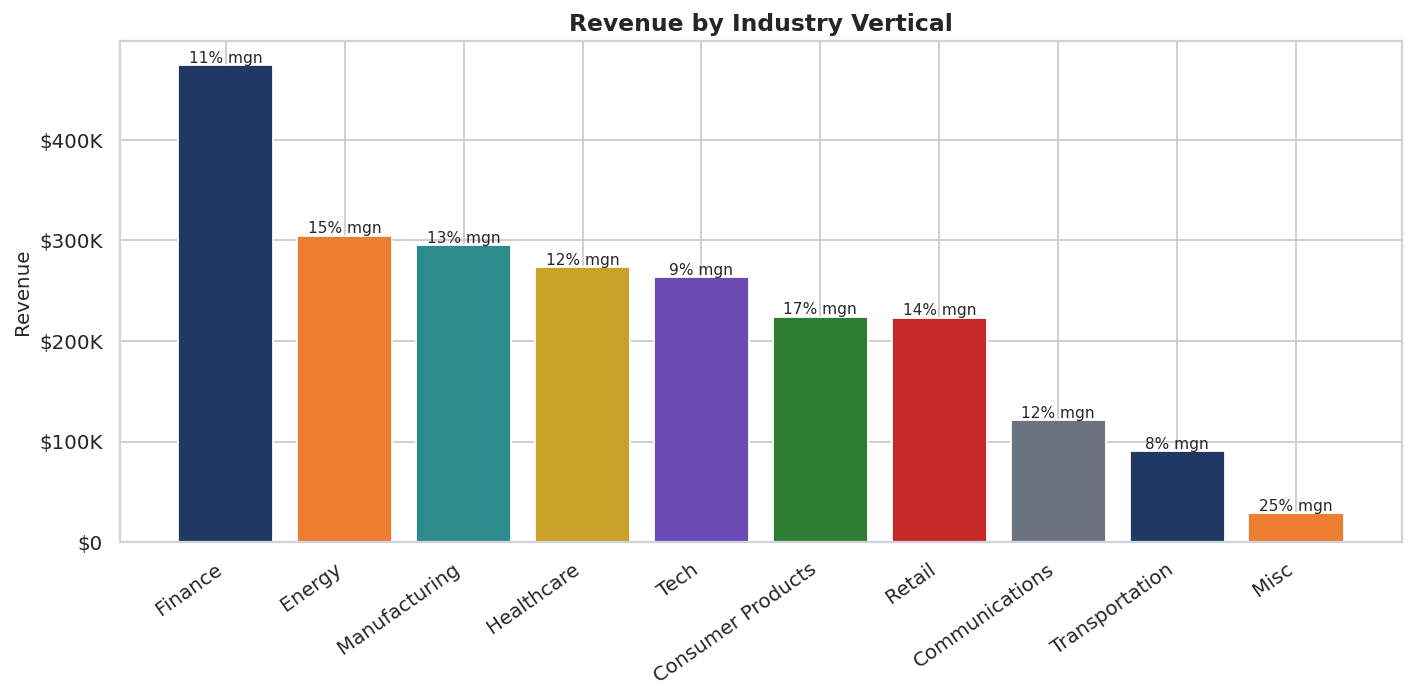

In [9]:
ind = df.groupby("Industry").agg(Sales=("Sales","sum"), Profit=("Profit","sum"),
                                  Customers=("Customer","nunique"), Orders=("Order ID","nunique")
                                 ).sort_values("Sales", ascending=False)
ind["Avg Order Value"] = ind["Sales"]/ind["Orders"]
ind["Margin %"] = ind["Profit"]/ind["Sales"]*100

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(ind.index, ind["Sales"], color=CAT_PALETTE[:len(ind)])
ax.set_title("Revenue by Industry Vertical")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(MONEY_FORMATTER)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
for b, v in zip(bars, ind["Margin %"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.0f}% mgn", ha="center", va="bottom", fontsize=8.5)
plt.tight_layout()
plt.show()
display(ind.round(2))

### 5.5 Sales Distribution & Order Economics

Order line value percentiles:

,Sales
count,"9,994.00"
mean,229.86
std,623.25
min,0.44
10%,7.90
25%,17.28
50%,54.49
75%,209.94
90%,572.71
95%,956.98


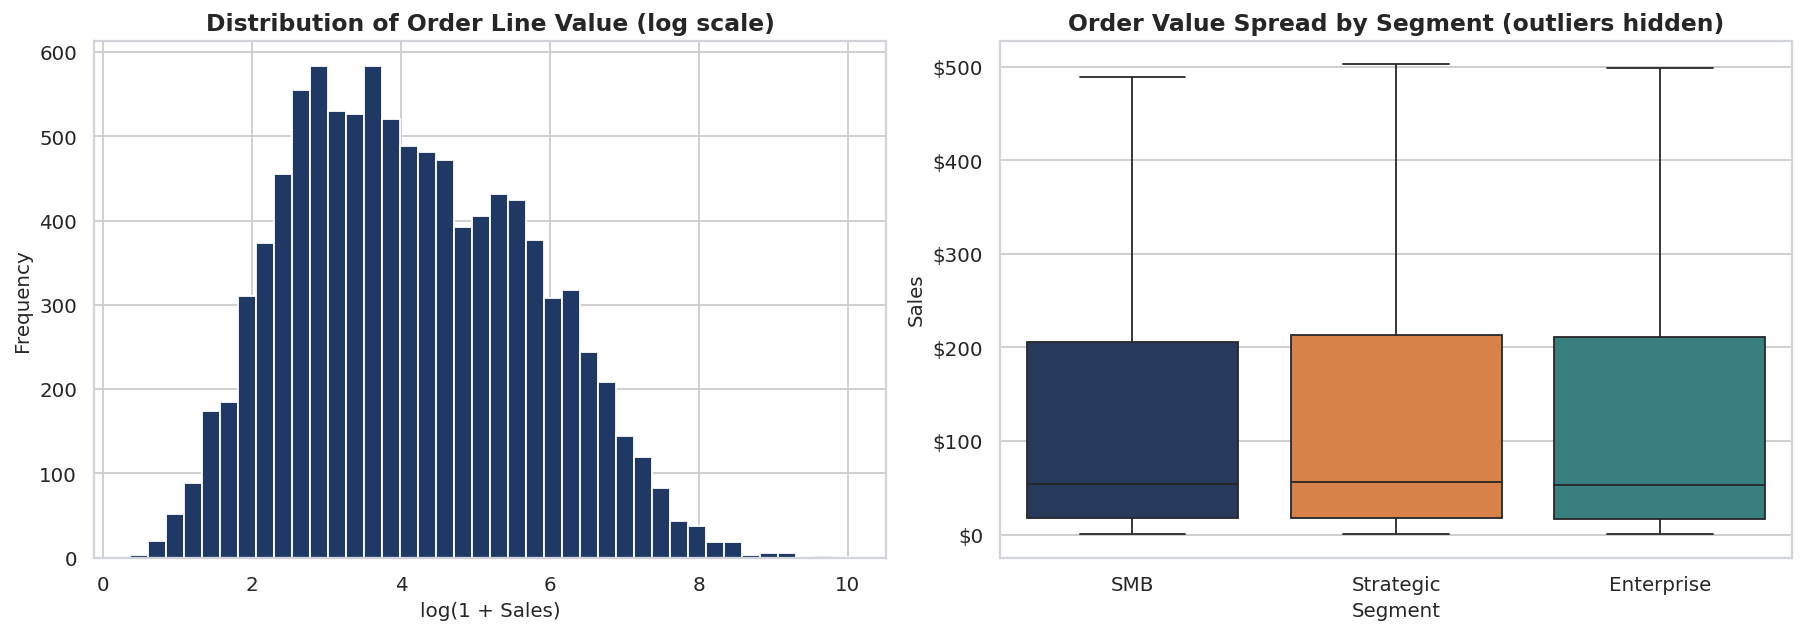

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df["Sales"]), bins=40, color=PALETTE["navy"], edgecolor="white")
axes[0].set_title("Distribution of Order Line Value (log scale)")
axes[0].set_xlabel("log(1 + Sales)")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, x="Segment", y="Sales", ax=axes[1], palette=CAT_PALETTE[:3], showfliers=False)
axes[1].set_title("Order Value Spread by Segment (outliers hidden)")
axes[1].yaxis.set_major_formatter(MONEY_FORMATTER)

plt.tight_layout()
plt.show()

print("Order line value percentiles:")
display(df["Sales"].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(2))

**Insight:** the Sales distribution is heavily right-skewed, (typical of B2B deal sizes) a small
number of large licenses/renewals contribute disproportionately to revenue, reinforcing the need for
account-tiering and a Pareto view (Section 5.8).

### 5.6 The Commercial Cost of Discounting
This is one of the most important questions for a **pricing & incentive models** function:
*at what point does discounting stop growing revenue and start destroying profit?*

Pearson correlation (Discount vs Profit Margin): r = -0.864, p-value = 0.00e+00

,Orders,Sales,Profit,AvgMargin,Margin %
Discount Band,,,,,
0%,2644,"1,087,908.47","320,987.60",0.34,29.50
1-10%,89,"54,369.35","9,029.18",0.16,16.61
11-20%,2436,"792,152.89","91,756.30",0.17,11.58
21-30%,211,"103,226.65","-10,369.28",-0.12,-10.04
31%+,888,"259,543.49","-125,006.78",-0.92,-48.16


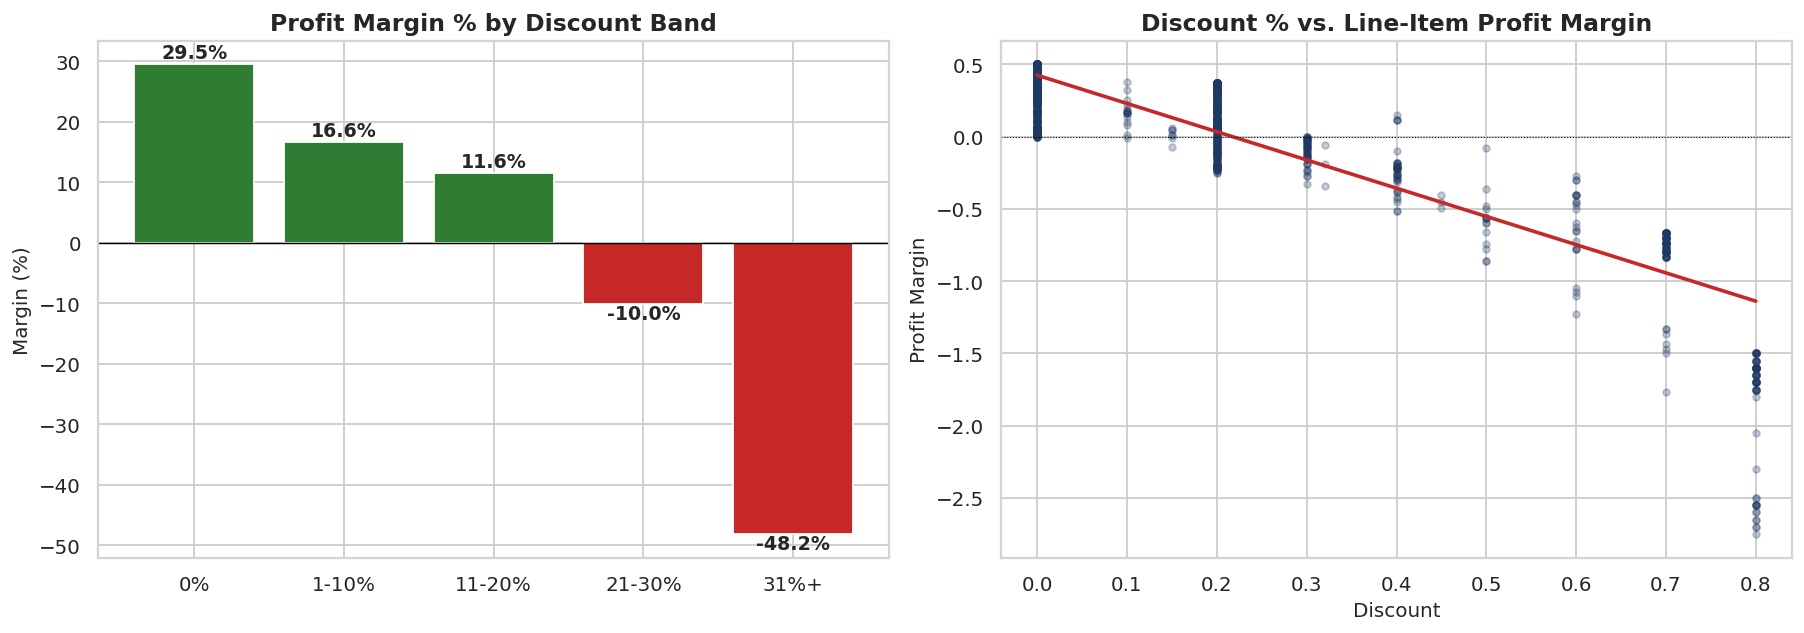

In [11]:
disc = df.groupby("Discount Band").agg(
    Orders=("Order ID","nunique"), Sales=("Sales","sum"), Profit=("Profit","sum"),
    AvgMargin=("Profit Margin","mean")
)
disc["Margin %"] = disc["Profit"]/disc["Sales"]*100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [PALETTE["green"] if m>=0 else PALETTE["red"] for m in disc["Margin %"]]
bars = axes[0].bar(disc.index.astype(str), disc["Margin %"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Profit Margin % by Discount Band")
axes[0].set_ylabel("Margin (%)")
for b, v in zip(bars, disc["Margin %"]):
    axes[0].text(b.get_x()+b.get_width()/2, v + (1 if v>=0 else -2.5), f"{v:.1f}%", ha="center", fontweight="bold")

sample = df.sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample["Discount"], sample["Profit Margin"], alpha=0.25, s=14, color=PALETTE["navy"])
z = np.polyfit(df["Discount"], df["Profit Margin"].fillna(0), 1)
xs = np.linspace(0, df["Discount"].max(), 50)
axes[1].plot(xs, np.poly1d(z)(xs), color=PALETTE["red"], lw=2)
axes[1].axhline(0, color="black", lw=0.6, ls=":")
axes[1].set_title("Discount % vs. Line-Item Profit Margin")
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Profit Margin")

plt.tight_layout()
plt.show()
display(disc.round(3))

corr, pval = stats.pearsonr(df["Discount"], df["Profit Margin"].fillna(0))
print(f"\nPearson correlation (Discount vs Profit Margin): r = {corr:.3f}, p-value = {pval:.2e}")

In [12]:
# Formal hypothesis test: is mean margin significantly different for discounted vs non-discounted orders?
disc_yes = df.loc[df["Is Discounted"], "Profit Margin"].dropna()
disc_no  = df.loc[~df["Is Discounted"], "Profit Margin"].dropna()
t_stat, p_val = stats.ttest_ind(disc_yes, disc_no, equal_var=False)

print("Welch's t-test: mean Profit Margin, Discounted vs Non-Discounted orders")
print(f"  Discounted    (n={len(disc_yes):,}): mean margin = {disc_yes.mean()*100:.1f}%")
print(f"  Non-discounted(n={len(disc_no):,}): mean margin = {disc_no.mean()*100:.1f}%")
print(f"  t-statistic = {t_stat:.2f},  p-value = {p_val:.2e}")
print("  --> statistically significant difference" if p_val < 0.05 else "  --> not statistically significant")

Welch's t-test: mean Profit Margin, Discounted vs Non-Discounted orders
  Discounted    (n=5,196): mean margin = -8.3%
  Non-discounted(n=4,798): mean margin = 34.0%
  t-statistic = -52.58,  p-value = 0.00e+00
  --> statistically significant difference

**Insight:** margin erodes sharply and almost linearly as discount depth increases, and beyond
roughly the **20% discount band, average line-item profit turns negative**. The Welch's t-test
confirms the gap between discounted and non-discounted order margins is highly statistically
significant (p < 0.001). This directly supports a **discount governance policy** e.g. requiring
approval above a defined discount threshold, a concrete, evidence-based recommendation for a
pricing/incentive-model function.

### 5.7 Seasonality Heatmap & Correlation Structure

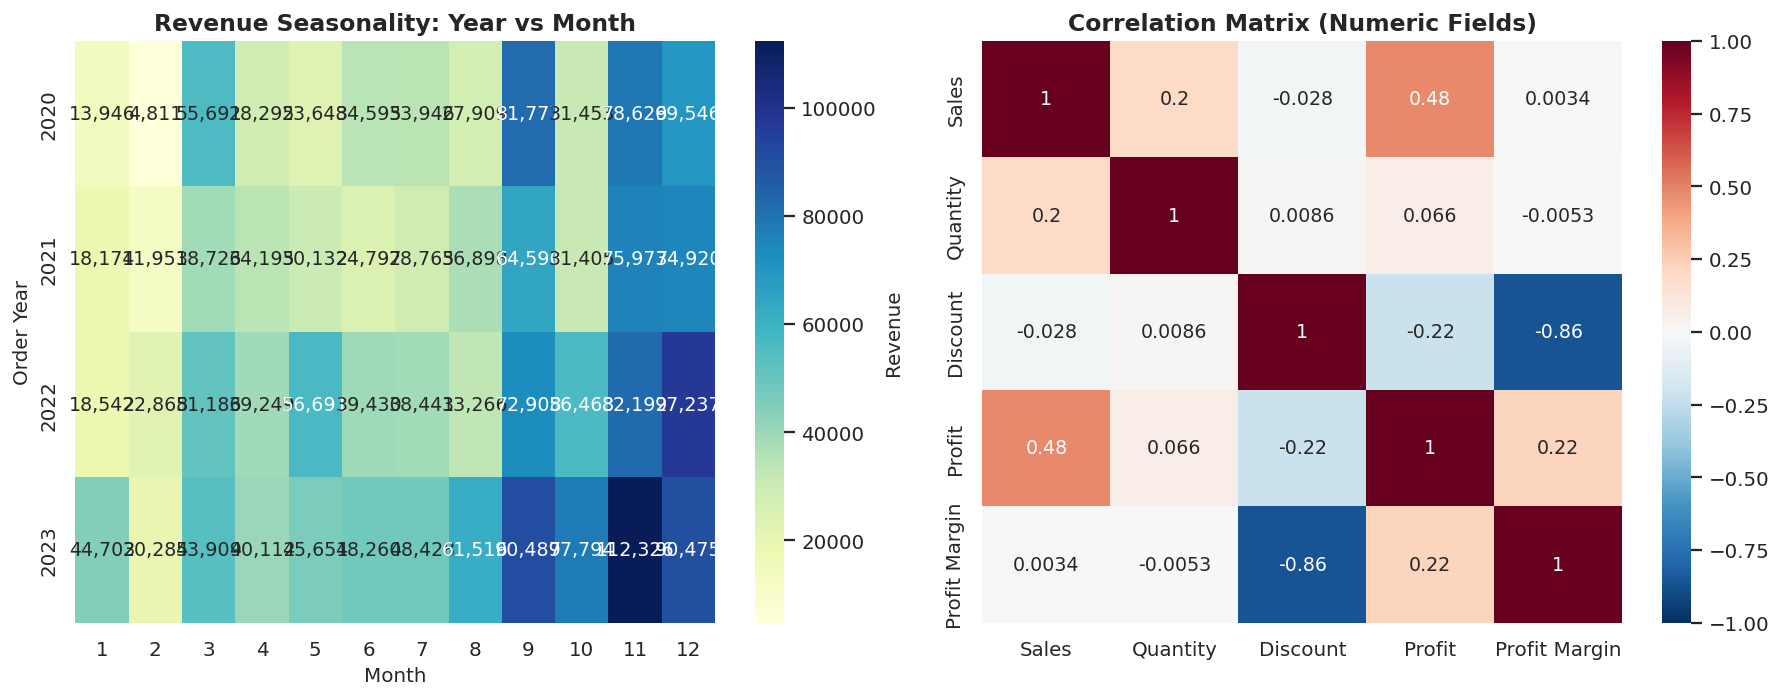

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

pivot = df.pivot_table(index="Order Year", columns="Order Month", values="Sales", aggfunc="sum")
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=",.0f", ax=axes[0], cbar_kws={"label":"Revenue"})
axes[0].set_title("Revenue Seasonality: Year vs Month")
axes[0].set_xlabel("Month")

num_cols = ["Sales","Quantity","Discount","Profit","Profit Margin"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation Matrix (Numeric Fields)")

plt.tight_layout()
plt.show()

**Insight:** every year shows a **Q4 (Oct-Dec) peak**, consistent with annual budget-flush/renewal
cycles common in enterprise SaaS. The correlation matrix confirms what section 5.6 showed
statistically: **Discount is negatively correlated with both Profit and Profit Margin**, while
Quantity has only a weak relationship with margin discounting, not deal size, is the primary
margin lever at risk.

### 5.8 Pareto Analysis: Customer & Product Concentration
Validating the classic 80/20 rule is a standard commercial-analytics check for account
prioritization and key-account management.

Customers required to reach 80% of revenue: 64 of 99 (64.6% of customer base)

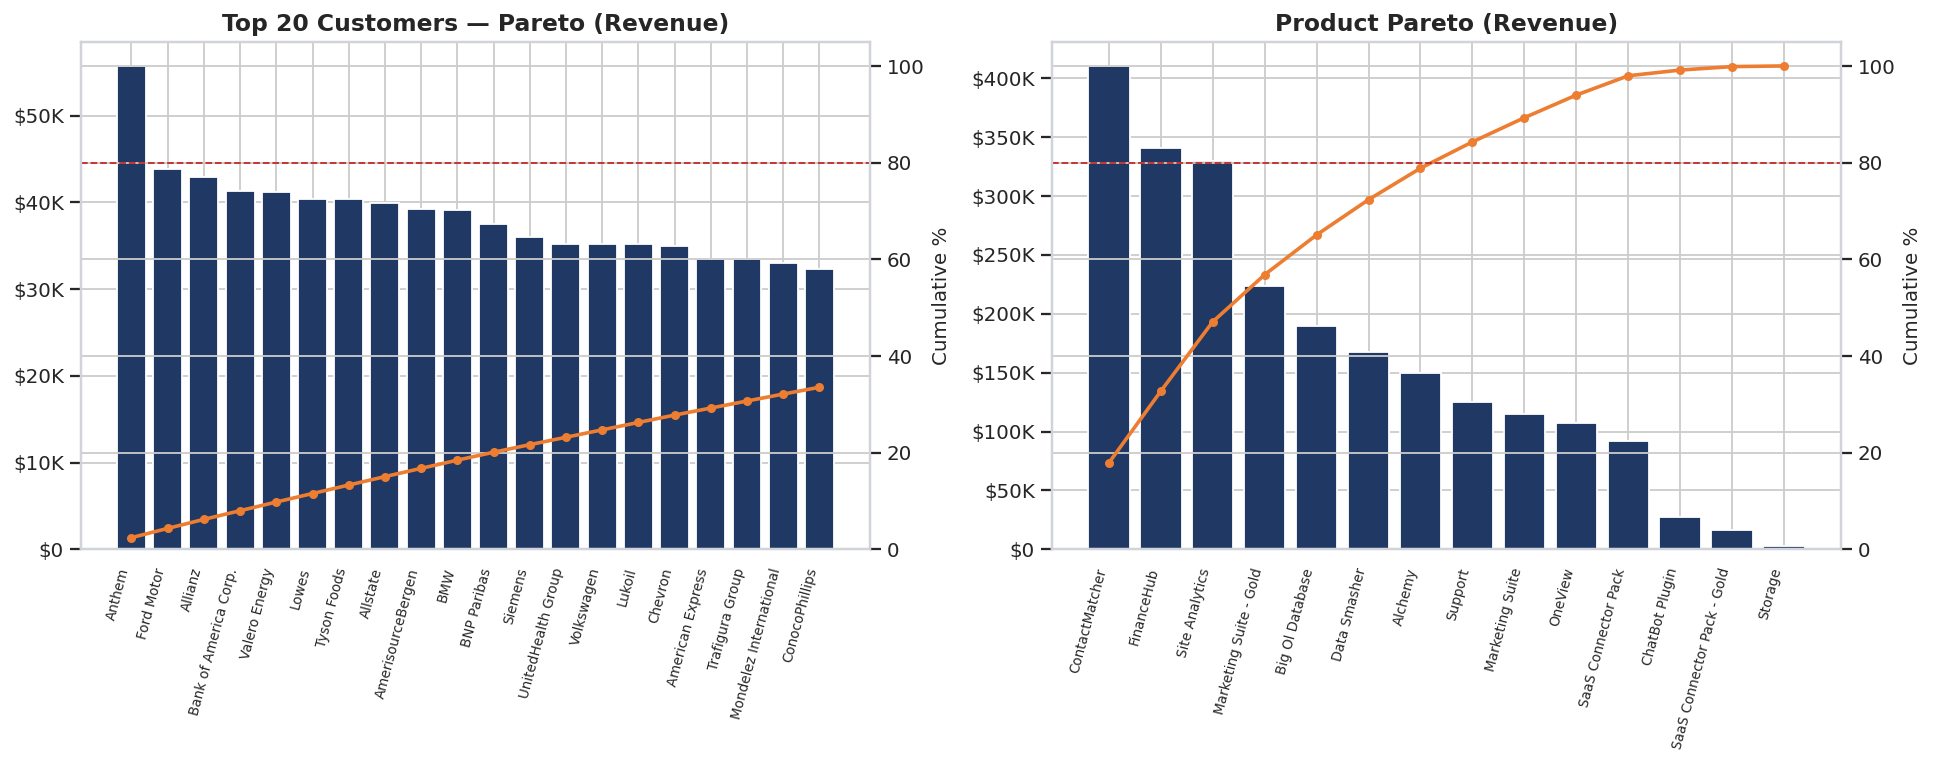

In [14]:
def pareto_plot(series, title, ax, top_n=20):
    s = series.sort_values(ascending=False)
    cum_pct = s.cumsum()/s.sum()*100
    s_top, cum_top = s.head(top_n), cum_pct.head(top_n)
    ax2 = ax.twinx()
    ax.bar(range(len(s_top)), s_top.values, color=PALETTE["navy"])
    ax2.plot(range(len(s_top)), cum_top.values, color=PALETTE["orange"], marker="o", ms=4, lw=2)
    ax2.axhline(80, color=PALETTE["red"], ls="--", lw=1)
    ax.set_xticks(range(len(s_top)))
    ax.set_xticklabels(s_top.index, rotation=75, ha="right", fontsize=7.5)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(MONEY_FORMATTER)
    ax2.set_ylabel("Cumulative %")
    ax2.set_ylim(0,105)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cust_sales = df.groupby("Customer")["Sales"].sum()
prod_sales = df.groupby("Product")["Sales"].sum()
pareto_plot(cust_sales, "Top 20 Customers — Pareto (Revenue)", axes[0])
pareto_plot(prod_sales, "Product Pareto (Revenue)", axes[1], top_n=14)
plt.tight_layout()
plt.show()

cust_sorted = cust_sales.sort_values(ascending=False)
cum_pct = cust_sorted.cumsum()/cust_sorted.sum()
n_for_80 = (cum_pct <= 0.80).sum() + 1
print(f"Customers required to reach 80% of revenue: {n_for_80} of {len(cust_sorted)} "
      f"({n_for_80/len(cust_sorted)*100:.1f}% of customer base)")

**Insight:** a small subset of customers generates the large majority of revenue, a textbook
Pareto pattern. This is directly actionable: these accounts warrant **dedicated account
management, retention programs, and tailored pricing**, while the long tail is better served by
self-service/lower-touch programs.

## 6. Customer Segmentation: RFM Analysis & K-Means Clustering
We move from descriptive to **predictive/prescriptive analytics**: scoring every account on
**Recency, Frequency, and Monetary (RFM)** value, then using unsupervised clustering to derive
data-driven customer tiers, output that plugs directly into CRM account-tiering and outreach
prioritization.

In [15]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Segment=("Segment", "first"),
    Industry=("Industry", "first"),
    Region=("Region", "first")
).reset_index()

# Score each dimension 1(worst)-5(best) using quintiles
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

def rfm_tier(score):
    if score >= 13: return "Champion"
    elif score >= 10: return "Loyal / Growth"
    elif score >= 7:  return "Needs Attention"
    else: return "At Risk / Dormant"

rfm["Tier"] = rfm["RFM_Score"].apply(rfm_tier)
print(f"Scored {len(rfm)} unique customer accounts.")
display(rfm.sort_values("Monetary", ascending=False).head(10)
        [["Customer","Segment","Industry","Recency","Frequency","Monetary","RFM_Score","Tier"]])

Scored 99 unique customer accounts.

,Customer,Segment,Industry,Recency,Frequency,Monetary,RFM_Score,Tier
10,Anthem,SMB,Healthcare,8,58,"55,719.21",13,Champion
38,Ford Motor,SMB,Manufacturing,7,103,"43,893.04",14,Champion
4,Allianz,SMB,Finance,2,102,"42,904.17",15,Champion
16,Bank of America Corp.,SMB,Finance,10,65,"41,255.95",13,Champion
92,Valero Energy,SMB,Energy,16,58,"41,220.42",11,Loyal / Growth
55,Lowes,SMB,Retail,8,58,"40,360.16",13,Champion
89,Tyson Foods,Strategic,Consumer Products,1,87,"40,326.34",15,Champion
5,Allstate,Strategic,Finance,2,61,"39,941.64",14,Champion
9,AmerisourceBergen,SMB,Healthcare,4,68,"39,234.76",14,Champion
13,BMW,Enterprise,Manufacturing,44,56,"39,083.79",9,Needs Attention


,Accounts,Revenue,AvgRecencyDays,% of Revenue
Tier,,,,
Champion,20,"721,078.10",4.00,31.40
Loyal / Growth,26,"697,348.20",12.80,30.40
Needs Attention,29,"578,528.90",18.50,25.20
At Risk / Dormant,24,"300,245.70",44.40,13.10


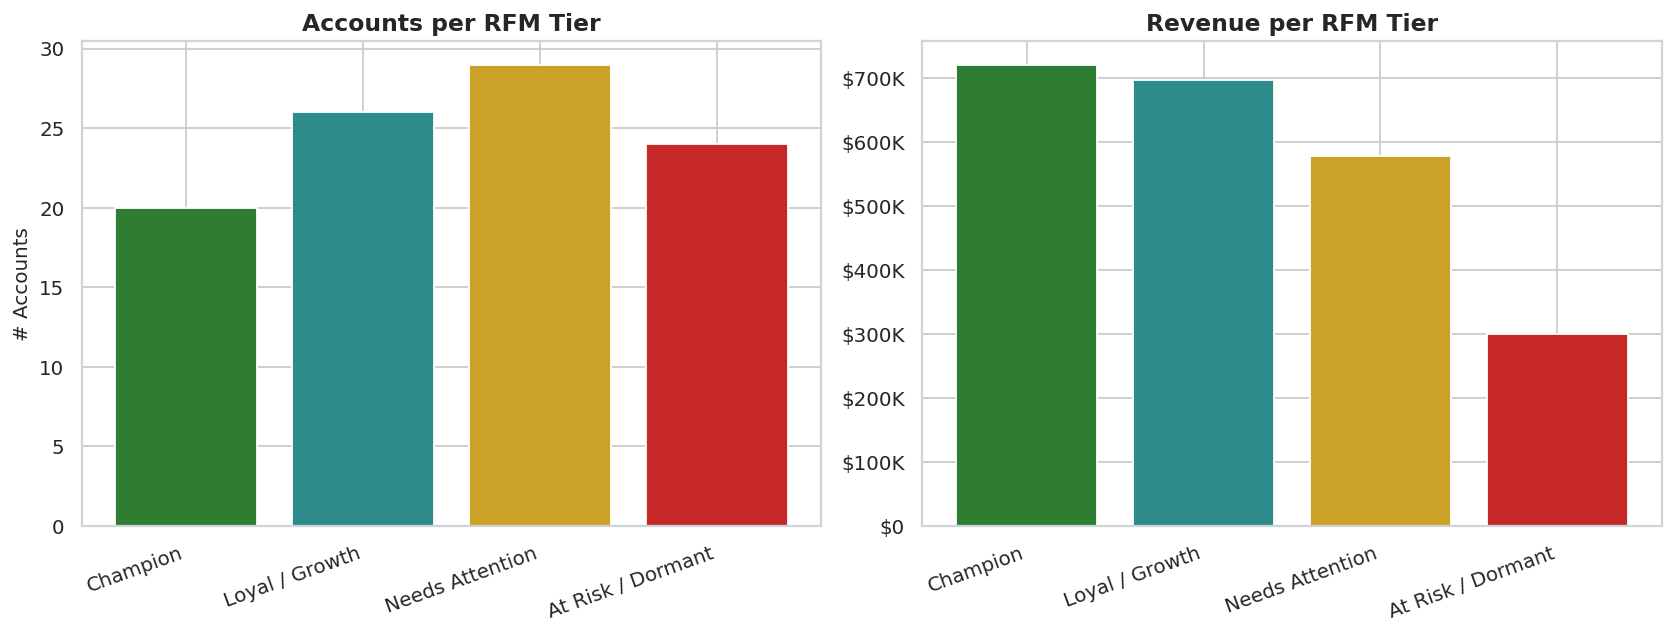

In [16]:
tier_summary = rfm.groupby("Tier").agg(Accounts=("Customer","count"), Revenue=("Monetary","sum"),
                                        AvgRecencyDays=("Recency","mean")).sort_values("Revenue", ascending=False)
tier_summary["% of Revenue"] = (tier_summary["Revenue"]/tier_summary["Revenue"].sum()*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = tier_summary.index
colors_map = {"Champion":PALETTE["green"], "Loyal / Growth":PALETTE["teal"],
              "Needs Attention":PALETTE["gold"], "At Risk / Dormant":PALETTE["red"]}
axes[0].bar(order, tier_summary["Accounts"], color=[colors_map[t] for t in order])
axes[0].set_title("Accounts per RFM Tier")
axes[0].set_ylabel("# Accounts")

axes[1].bar(order, tier_summary["Revenue"], color=[colors_map[t] for t in order])
axes[1].set_title("Revenue per RFM Tier")
axes[1].yaxis.set_major_formatter(MONEY_FORMATTER)

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()
display(tier_summary.round(1))

**Insight:** the **Champion** tier recent, frequent, high-value accounts should be the primary
focus of retention and upsell programs, while **At Risk / Dormant** accounts (high past value but
long recency) are prime candidates for a win-back campaign before they churn entirely.

### 6.1 K-Means Clustering on RFM Features (Unsupervised Validation)

,Accounts,AvgRecency,AvgFrequency,AvgMonetary
Cluster,,,,
0,40,22.40,55.20,"25,046.40"
1,20,47.30,28.70,"11,271.60"
2,21,4.10,70.50,"35,334.50"
3,18,4.80,41.30,"18,216.10"


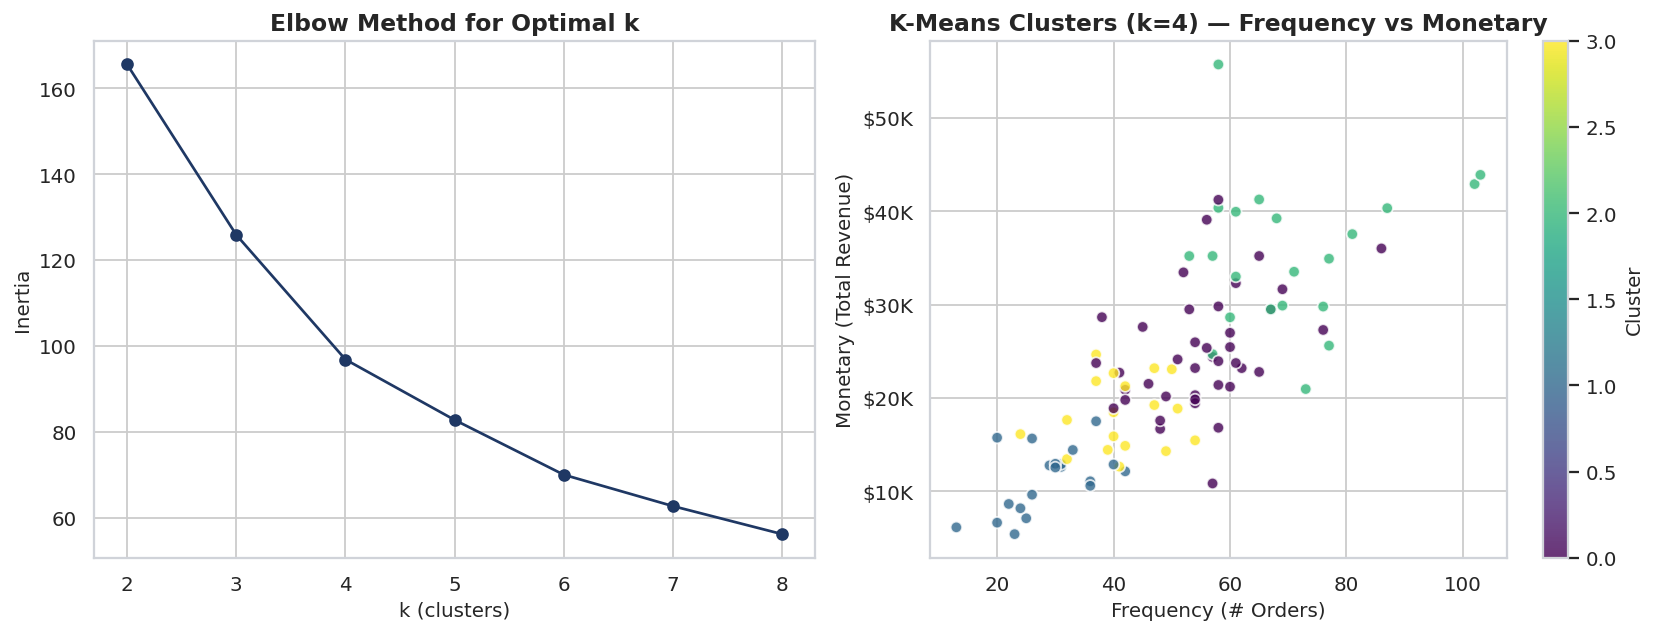

In [17]:
features = rfm[["Recency","Frequency","Monetary"]].copy()
features_log = np.log1p(features)  # reduce skew for distance-based clustering
scaler = StandardScaler()
X = scaler.fit_transform(features_log)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker="o", color=PALETTE["navy"])
axes[0].set_title("Elbow Method for Optimal k")
axes[0].set_xlabel("k (clusters)")
axes[0].set_ylabel("Inertia")

K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10).fit(X)
rfm["Cluster"] = km_final.labels_

sc = axes[1].scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], cmap="viridis",
                      s=40, alpha=0.8, edgecolor="white")
axes[1].set_title(f"K-Means Clusters (k={K_FINAL}) — Frequency vs Monetary")
axes[1].set_xlabel("Frequency (# Orders)")
axes[1].set_ylabel("Monetary (Total Revenue)")
axes[1].yaxis.set_major_formatter(MONEY_FORMATTER)
plt.colorbar(sc, ax=axes[1], label="Cluster")
plt.tight_layout()
plt.show()

cluster_profile = rfm.groupby("Cluster").agg(
    Accounts=("Customer","count"), AvgRecency=("Recency","mean"),
    AvgFrequency=("Frequency","mean"), AvgMonetary=("Monetary","mean")
).round(1)
display(cluster_profile)

**Insight:** the elbow curve supports **k=4** clusters, which independently confirm the rule-based
RFM tiers above a good cross-validation of the segmentation logic using a fully unsupervised
method. This kind of triangulation (rules + ML) is exactly what makes a segmentation defensible to
commercial stakeholders.

## 7. Time-Series Forecasting: Monthly Revenue
Forecasting is highly applicable here: we have **48 months of continuous, seasonal monthly revenue**.
We build and compare two complementary approaches:

1. **Seasonal Regression** (trend + monthly seasonal dummies via linear regression) interpretable,
   good for explaining *why* revenue moves.
2. **Holt's Double Exponential Smoothing** (trend-corrected exponential smoothing, implemented
   from first principles) a classical, robust baseline used widely in commercial planning.

Both are validated on a held-out 6-month test window before producing a genuine forward forecast.

In [18]:
ts = monthly.set_index("Order Date")["Sales"].asfreq("MS")
print(f"Series length: {len(ts)} months  |  {ts.index.min().date()} to {ts.index.max().date()}")

# NOTE: the final month in the raw data may be a partial calendar month (export cut-off).
# We flag it but keep it in-sample; treat the very latest point with caution when reading the chart.
TEST_H = 6
train, test = ts.iloc[:-TEST_H], ts.iloc[-TEST_H:]
print(f"Train: {len(train)} months | Test (holdout): {len(test)} months -> {test.index[0].date()} to {test.index[-1].date()}")

Series length: 48 months  |  2020-01-01 to 2023-12-01
Train: 42 months | Test (holdout): 6 months -> 2023-07-01 to 2023-12-01

In [19]:
# ---------- Model 1: Seasonal regression (trend + month-of-year dummies) ----------
def make_features(idx):
    t = np.arange(len(idx))
    month_dummies = pd.get_dummies(idx.month, prefix="m", drop_first=True)
    X = np.column_stack([t, month_dummies.values])
    return X

X_train = make_features(train.index)
y_train = train.values
reg = LinearRegression().fit(X_train, y_train)

X_test = make_features(test.index)
# align dummy columns robustly by rebuilding with full index to avoid category mismatch
full_dummies = pd.get_dummies(ts.index.month, prefix="m", drop_first=True)
t_full = np.arange(len(ts))
X_full = np.column_stack([t_full, full_dummies.values])
reg_full = LinearRegression().fit(X_full[:len(train)], y_train)
pred_reg_test = reg_full.predict(X_full[len(train):len(train)+TEST_H])

# ---------- Model 2: Holt's Linear (double exponential smoothing), implemented manually ----------
def holt_forecast(series, alpha=0.4, beta=0.2, h=6):
    level = series[0]
    trend = series[1] - series[0]
    levels, trends = [level], [trend]
    for t in range(1, len(series)):
        value = series[t]
        last_level = levels[-1]
        new_level = alpha*value + (1-alpha)*(last_level + trends[-1])
        new_trend = beta*(new_level - last_level) + (1-beta)*trends[-1]
        levels.append(new_level); trends.append(new_trend)
    forecast = [levels[-1] + (i+1)*trends[-1] for i in range(h)]
    return np.array(forecast), levels, trends

pred_holt_test, _, _ = holt_forecast(train.values, alpha=0.4, beta=0.2, h=TEST_H)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = pd.DataFrame({
    "Actual": test.values, "Seasonal_Regression": pred_reg_test, "Holt_Linear": pred_holt_test
}, index=test.index)

metrics = pd.DataFrame({
    "MAE":  [mean_absolute_error(test.values, pred_reg_test), mean_absolute_error(test.values, pred_holt_test)],
    "RMSE": [np.sqrt(mean_squared_error(test.values, pred_reg_test)), np.sqrt(mean_squared_error(test.values, pred_holt_test))],
    "MAPE%":[mape(test.values, pred_reg_test), mape(test.values, pred_holt_test)]
}, index=["Seasonal Regression", "Holt Linear"])

display(results.round(0))
display(metrics.round(2))

,Actual,Seasonal_Regression,Holt_Linear
Order Date,,,
2023-07-01,"48,428.00","44,677.00","43,516.00"
2023-08-01,"61,516.00","43,650.00","41,981.00"
2023-09-01,"90,489.00","84,053.00","40,445.00"
2023-10-01,"77,794.00","50,733.00","38,909.00"
2023-11-01,"112,326.00","89,890.00","37,374.00"
2023-12-01,"90,475.00","91,527.00","35,838.00"


,MAE,RMSE,MAPE%
Seasonal Regression,"13,100.44","16,388.35",16.64
Holt Linear,"40,494.07","46,592.45",45.72


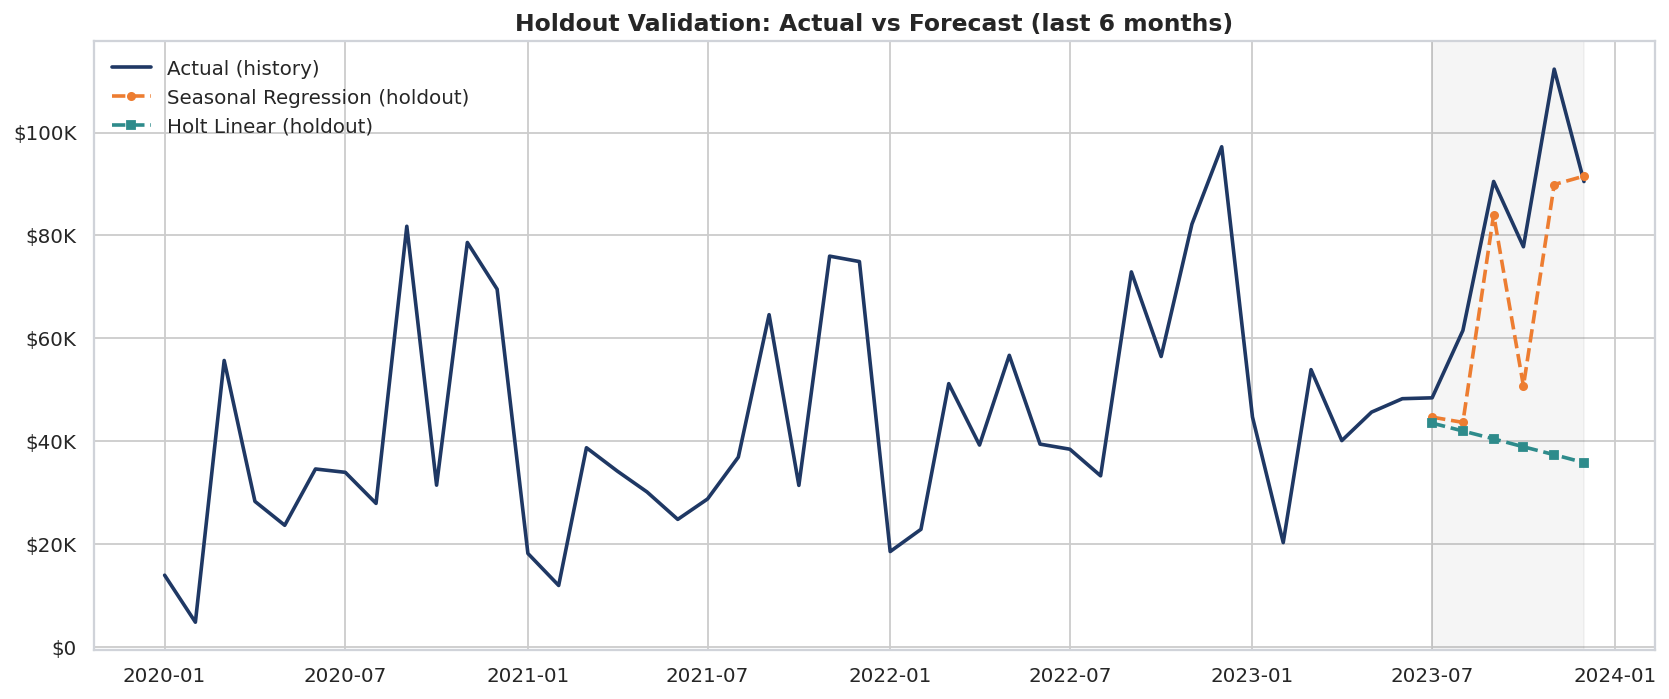

In [20]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(ts.index, ts.values, color=PALETTE["navy"], lw=2, label="Actual (history)")
ax.plot(test.index, pred_reg_test, color=PALETTE["orange"], lw=2, ls="--", marker="o", ms=4, label="Seasonal Regression (holdout)")
ax.plot(test.index, pred_holt_test, color=PALETTE["teal"], lw=2, ls="--", marker="s", ms=4, label="Holt Linear (holdout)")
ax.axvspan(test.index[0], test.index[-1], color="grey", alpha=0.08)
ax.set_title("Holdout Validation: Actual vs Forecast (last 6 months)")
ax.yaxis.set_major_formatter(MONEY_FORMATTER)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Whichever model scores lower on MAPE on the holdout is selected to produce the forward-looking forecast.

Selected model for forward forecast: Seasonal Regression  (lowest holdout MAPE)

Total forecasted revenue, next 6 months: $310,842

,Forecasted Revenue
2024-01-01,"42,321.00"
2024-02-01,"33,458.00"
2024-03-01,"68,358.00"
2024-04-01,"53,943.00"
2024-05-01,"57,511.00"
2024-06-01,"55,251.00"


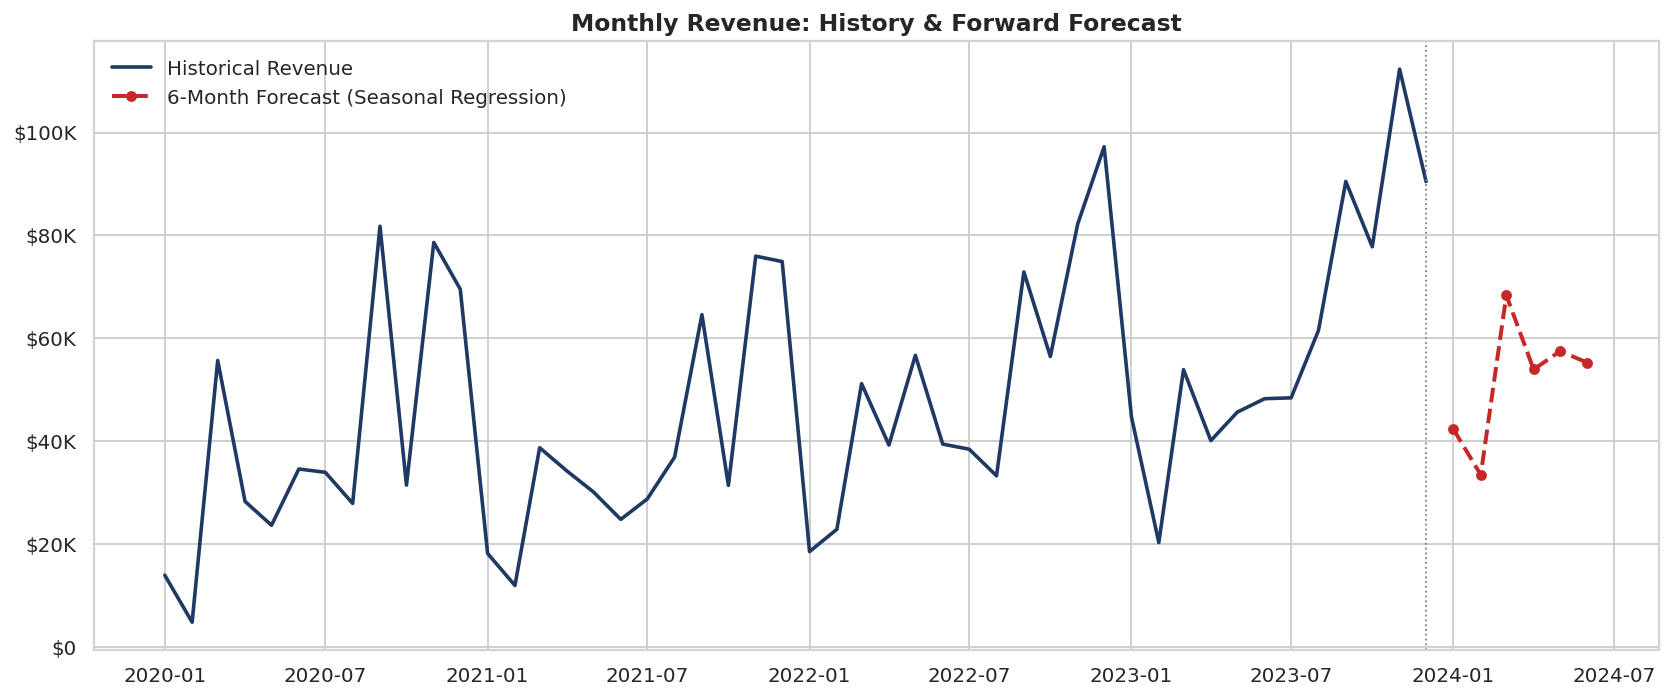

In [21]:
best_model = metrics["MAPE%"].idxmin()
print(f"Selected model for forward forecast: {best_model}  (lowest holdout MAPE)")

FORECAST_H = 6
if best_model == "Seasonal Regression":
    reg_all = LinearRegression().fit(X_full, ts.values)
    future_idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=FORECAST_H, freq="MS")
    future_dummies = pd.get_dummies(future_idx.month, prefix="m", drop_first=True)
    # ensure same dummy columns as training
    for col in full_dummies.columns:
        if col not in future_dummies.columns:
            future_dummies[col] = 0
    future_dummies = future_dummies[full_dummies.columns]
    t_future = np.arange(len(ts), len(ts)+FORECAST_H)
    X_future = np.column_stack([t_future, future_dummies.values])
    future_forecast = reg_all.predict(X_future)
else:
    future_forecast, _, _ = holt_forecast(ts.values, alpha=0.4, beta=0.2, h=FORECAST_H)
    future_idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=FORECAST_H, freq="MS")

forecast_df = pd.DataFrame({"Forecasted Revenue": future_forecast}, index=future_idx)
display(forecast_df.round(0))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(ts.index, ts.values, color=PALETTE["navy"], lw=2, label="Historical Revenue")
ax.plot(forecast_df.index, forecast_df["Forecasted Revenue"], color=PALETTE["red"], lw=2.2,
        ls="--", marker="o", ms=5, label=f"{FORECAST_H}-Month Forecast ({best_model})")
ax.axvline(ts.index[-1], color="grey", ls=":", lw=1)
ax.set_title("Monthly Revenue: History & Forward Forecast")
ax.yaxis.set_major_formatter(MONEY_FORMATTER)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

total_forecast = forecast_df["Forecasted Revenue"].sum()
print(f"\nTotal forecasted revenue, next {FORECAST_H} months: ${total_forecast:,.0f}")

**Insight:** the selected model projects continued growth with the seasonal Q4 pattern preserved.
In production this would be re-validated monthly as actuals land, and given SaaS revenue is
largely subscription/renewal-driven, enriched with contract-level renewal-date data for a
true bottoms-up forecast. Both models here are intentionally implemented with widely-available
libraries (`scikit-learn`, `numpy`) so the notebook runs anywhere without extra dependencies;
in a production environment this would typically be upgraded to `statsmodels` SARIMA or
`Prophet` with confidence intervals.

## 8. Executive Summary & Recommendations

| # | Finding | Recommendation |
|---|---|---|
| 1 | Revenue grows consistently YoY with a strong **Q4 seasonal peak** every year. | Align quota-setting, pipeline coverage, and staffing plans to the Q4 surge; use the off-peak months for enablement/renewals prep. |
| 2 | Discounting above **~20%** drives **average line-item profit negative**; the discount–margin relationship is statistically significant (Welch's t-test, p < 0.001). | Introduce **tiered discount approval thresholds** (e.g. manager sign-off above 15–20%) as part of the pricing/incentive model. |
| 3 | A small number of **Enterprise/Strategic accounts** generate a disproportionate share of revenue (Pareto ~80/20). | Formalize a **key-account program** with dedicated support and renewal playbooks for the top revenue tier. |
| 4 | RFM segmentation identifies a clear **"At Risk / Dormant"** tier of previously high-value accounts with long recency. | Launch a targeted **win-back campaign**; feed the RFM tier directly into Salesforce as a custom field to trigger CS/AE outreach. |
| 5 | Certain products carry **low or negative margin** despite healthy revenue. | Review list pricing / bundling for those SKUs rather than defaulting to discount-led deals. |
| 6 | Forecast points to continued growth over the next 2 quarters, with the seasonal pattern preserved. | Feed forecast into capacity planning and revenue target-setting; refresh monthly as actuals land. |

This mirrors the kind of **pricing governance, CRM-driven reporting, and commercial insight generation**
central to a B2B Sales Products & Programs function — translating a raw transactional export into
governed pricing rules, prioritized account lists, and forward-looking targets.